In [ ]:
!pip install transformers==3.0.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.0/769.0 kB 20.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 40.7 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [59 lines of output]
      /tmp/pip-build-env-zl0d812n/overlay/lib/python3.10/site-packages/setuptools/dist.py:332: InformationOnly: Normalizing '0.8.1.rc1' to '0.8.1rc1'
        self.metadata.version = self._normalize_version(self.metadata.version)
      /tmp/pip-build-env-zl0d812n/overlay/lib/python3.10/site-packages/setuptools/dist.py:759: SetuptoolsDeprecationWarning: License classifiers ar

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import seaborn as sns
import transformers
import json
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import logging
from torch import cuda
from transformers import AutoTokenizer, AutoModel

logging.basicConfig(level=logging.ERROR)

# Select device
device = 'cuda' if cuda.is_available() else 'cpu'


In [ ]:
import pandas as pd

dataset_path = "/kaggle/input/experience-updated-upsampled-data/Experience updated upsampled_data.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully!")
df.head()


Dataset Loaded Successfully!


,Combined,Experience
0,"Name: Masum Rahman, Job_Title: Software Engine...",5
1,"Name: Majbah Uddin, Job_Title: Software Engine...",5
2,"Name: Mohammad Asif, Job_Title: Project Manage...",5
3,"Name: Robin Halder, Job_Title: Software Engine...",5
4,"Name: Masum Rahman, Job_Title: Software Engine...",5


In [ ]:
import re
import string

# Remove punctuations and unwanted characters
def strip_all_entities(text):
    text = text.replace('\r', '').replace('\n', ' ').lower()  # Remove \n and \r and lowercase
    text = re.sub(r"(?:\@|https?\://)\S+", "", text)
    text = re.sub(r'[^\x00-\x7f]', r'', text)  # Remove non-utf8/ascii characters
    banned_list = string.punctuation + 'Ã' + '±' + 'ã' + '¼' + 'â' + '»' + '§'
    table = str.maketrans('', '', banned_list)
    text = text.translate(table)
    return text

# Filter special characters such as & and $ present in some words
def filter_chars(a):
    sent = []
    for word in a.split(' '):
        if ('$' in word) | ('&' in word):
            sent.append('')
        else:
            sent.append(word)
    return ' '.join(sent)

# Remove multiple spaces
def remove_mult_spaces(text):
    return re.sub("\s\s+", " ", text)  # Replace multiple spaces with a single space

# Function to clean the raw text by applying all cleaning steps
def clean_text(text):
    text = strip_all_entities(text)
    text = filter_chars(text)
    text = remove_mult_spaces(text)
    return text

# Apply the clean_text function to the 'Combined' column and create a new 'CleanedText' column
df['CleanedText'] = df['Combined'].apply(clean_text)

# Display the first few rows of the DataFrame with the cleaned text
print(df[['Combined', 'CleanedText', 'Experience']].head())

df.to_csv('/kaggle/working/cleaned_data.csv', index=False)  # Replace with your desired file path

print("Cleaned text has been saved to 'cleaned_data.csv'.")


                                            Combined  \
0  Name: Masum Rahman, Job_Title: Software Engine...   
1  Name: Majbah Uddin, Job_Title: Software Engine...   
2  Name: Mohammad Asif, Job_Title: Project Manage...   
3  Name: Robin Halder, Job_Title: Software Engine...   
4  Name: Masum Rahman, Job_Title: Software Engine...   

                                         CleanedText  Experience  
0  name masum rahman jobtitle software engineer a...           5  
1  name majbah uddin jobtitle software engineer a...           5  
2  name mohammad asif jobtitle project manager at...           5  
3  name robin halder jobtitle software engineer 7...           5  
4  name masum rahman jobtitle software engineer a...           5  
Cleaned text has been saved to 'cleaned_data.csv'.


In [ ]:
# Apply the clean_text function to the 'Combined' column
df['CleanedText'] = df['Combined'].apply(clean_text)

# Create the labels based on Skills score
def map_labels(score):
    if score == 1 or score == 2:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral
    elif score == 4 or score == 5:
        return 2  # Positive

# Strip any leading or trailing spaces
df.columns = df.columns.str.strip()

# Apply the mapping function to the 'Experience' column
df['Experience_Label'] = df['Experience'].apply(map_labels)

print("Mapped Experience Labels:")
print(df['Experience_Label'].value_counts())

print(df.head())
df.to_csv('/kaggle/working/experience_labels.csv', index=False)

Mapped Experience Labels:
Experience_Label
2    6008
0    3688
1    1368
Name: count, dtype: int64
                                            Combined  Experience  \
0  Name: Masum Rahman, Job_Title: Software Engine...           5   
1  Name: Majbah Uddin, Job_Title: Software Engine...           5   
2  Name: Mohammad Asif, Job_Title: Project Manage...           5   
3  Name: Robin Halder, Job_Title: Software Engine...           5   
4  Name: Masum Rahman, Job_Title: Software Engine...           5   

                                         CleanedText  Experience_Label  
0  name masum rahman jobtitle software engineer a...                 2  
1  name majbah uddin jobtitle software engineer a...                 2  
2  name mohammad asif jobtitle project manager at...                 2  
3  name robin halder jobtitle software engineer 7...                 2  
4  name masum rahman jobtitle software engineer a...                 2  


In [ ]:
from transformers import AutoTokenizer
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("Peraboom/LastBERT")

# Load your CSV
df = pd.read_csv("/kaggle/working/experience_labels.csv")

# Function to tokenize the text using the tokenizer
def tokenize_function(text):
    return tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors='pt'
    )

# Apply tokenization to the 'Combined' column
df['tokenized'] = df['Combined'].apply(lambda x: tokenize_function(x))

print(df['tokenized'].head())
print(df[['Combined', 'Experience_Label']].head())


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

0    [input_ids, token_type_ids, attention_mask]
1    [input_ids, token_type_ids, attention_mask]
2    [input_ids, token_type_ids, attention_mask]
3    [input_ids, token_type_ids, attention_mask]
4    [input_ids, token_type_ids, attention_mask]
Name: tokenized, dtype: object
                                            Combined  Experience_Label
0  Name: Masum Rahman, Job_Title: Software Engine...                 2
1  Name: Majbah Uddin, Job_Title: Software Engine...                 2
2  Name: Mohammad Asif, Job_Title: Project Manage...                 2
3  Name: Robin Halder, Job_Title: Software Engine...                 2
4  Name: Masum Rahman, Job_Title: Software Engine...                 2


In [ ]:
from transformers import AutoTokenizer

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/experience_labels.csv")  # This is your labeled data file


# Split the data into training (80%), validation (10%), and test (10%) sets
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Check the shape of the split data
print(f"Training Data Shape: {train_data.shape}")
print(f"Validation Data Shape: {val_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

output_dir = "/kaggle/working/"

train_data.to_csv(f"{output_dir}train_data.csv", index=False)
val_data.to_csv(f"{output_dir}val_data.csv", index=False)
test_data.to_csv(f"{output_dir}test_data.csv", index=False)


print("train_data.csv")
print("val_data.csv")
print("test_data.csv")


Training Data Shape: (8851, 4)
Validation Data Shape: (1106, 4)
Test Data Shape: (1107, 4)
train_data.csv
val_data.csv
test_data.csv


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer

class SkillsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        text = str(self.data.iloc[idx]['Combined'])
        label = self.data.iloc[idx]['Experience_Label']


        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
            return_token_type_ids=True
        )

        # Extract the tensors from the encoding dictionary and squeeze the batch dimension
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        token_type_ids = encoding['token_type_ids'].squeeze(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids,
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = SkillsDataset(train_data, tokenizer)
val_dataset = SkillsDataset(val_data, tokenizer)

# Create DataLoader objects to handle batching
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

for batch in train_dataloader:
    print(f"Input IDs: {batch['input_ids']}")
    print(f"Attention Mask: {batch['attention_mask']}")
    print(f"Token Type IDs: {batch['token_type_ids']}")
    print(f"Labels: {batch['labels']}")
    break


Input IDs: tensor([[  101,  2171,  1024,  ...,  1011, 16713,   102],
        [  101,  2171,  1024,  ...,  2083,  8241,   102],
        [  101,  2171,  1024,  ...,     0,     0,     0],
        ...,
        [  101,  2171,  1024,  ...,     0,     0,     0],
        [  101,  2171,  1024,  ...,  2622,  1006,   102],
        [  101,  2171,  1024,  ...,     0,     0,     0]])
Attention Mask: tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]])
Token Type IDs: tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
Labels: tensor([2, 0, 0, 2, 0, 1, 0, 1, 0, 2, 2, 2, 2, 0, 2, 1])


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, AdamW

# Define the LastBERT-based model
class LastBERTClass(nn.Module):
    def __init__(self, num_labels=3):
        super(LastBERTClass, self).__init__()

        self.lastbert = AutoModelForSequenceClassification.from_pretrained(
            "Peraboom/LastBERT",
            num_labels=num_labels,
            ignore_mismatched_sizes=True  # <-- THIS FIXES THE size mismatch
        )

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # Forward pass through LastBERT
        output = self.lastbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        return output.logits

# Initialize the model
model = LastBERTClass(num_labels=3)  # Negative (0), Neutral (1), Positive (2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set up the loss function
criterion = nn.CrossEntropyLoss()

# Set up the optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)
print(model)


config.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/119M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Peraboom/LastBERT and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 384]) in the checkpoint and torch.Size([3, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


LastBERTClass(
  (lastbert): BertForSequenceClassification(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 384, padding_idx=0)
        (position_embeddings): Embedding(512, 384)
        (token_type_embeddings): Embedding(2, 384)
        (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-5): 6 x BertLayer(
            (attention): BertAttention(
              (self): BertSdpaSelfAttention(
                (query): Linear(in_features=384, out_features=384, bias=True)
                (key): Linear(in_features=384, out_features=384, bias=True)
                (value): Linear(in_features=384, out_features=384, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=384, out_features=

In [ ]:
!pip install peft


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 7.0 MB/s eta 0:00:00:00:0100:01


In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
import torch.nn as nn
from sklearn.model_selection import train_test_split

# Define the custom Dataset class to handle the text and labels
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = self.texts[item]
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Prepare data
texts = df['Combined'].tolist()
labels = df['Experience_Label'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

tokenizer = AutoTokenizer.from_pretrained("Peraboom/LastBERT")

train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_len=256)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, max_len=256)

# Create dataloaders for batching
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=8)  # increased batch size
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=8)

# Define the LastBERT model class
class LastBERTClass(nn.Module):
    def __init__(self, num_labels=3):
        super(LastBERTClass, self).__init__()

        self.lastbert = AutoModelForSequenceClassification.from_pretrained(
            "Peraboom/LastBERT",
            num_labels=num_labels,
            ignore_mismatched_sizes=True
        )

    def forward(self, input_ids, attention_mask):
        output = self.lastbert(input_ids=input_ids, attention_mask=attention_mask)
        return output.logits

# Initialize the model
model = LastBERTClass(num_labels=3)

# Use multiple GPUs with DataParallel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model.to(device)

# Set up optimizer and loss
optimizer = AdamW(model.parameters(), lr=1e-7, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Training and evaluation loop
def train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=19):
    best_val_loss = float('inf')
    patience = 2
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch in train_dataloader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(logits, dim=1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = running_loss / len(train_dataloader)
        train_accuracy = correct_train / total_train

        model.eval()
        correct_val = 0
        total_val = 0
        running_val_loss = 0.0

        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs

                loss = criterion(logits, labels)
                running_val_loss += loss.item()

                _, predicted = torch.max(logits, dim=1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = running_val_loss / len(val_dataloader)
        val_accuracy = correct_val / total_val

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

# Train the LastBERT model on multiple GPUs
train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=19)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Peraboom/LastBERT and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 384]) in the checkpoint and torch.Size([3, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):


Epoch 1/19
Training Loss: 1.0435, Training Accuracy: 0.4959
Validation Loss: 0.9919, Validation Accuracy: 0.5486
Epoch 2/19
Training Loss: 0.9750, Training Accuracy: 0.5417
Validation Loss: 0.9530, Validation Accuracy: 0.5486
Epoch 3/19
Training Loss: 0.9497, Training Accuracy: 0.5416
Validation Loss: 0.9357, Validation Accuracy: 0.5486
Epoch 4/19
Training Loss: 0.9349, Training Accuracy: 0.5416
Validation Loss: 0.9195, Validation Accuracy: 0.5486
Epoch 5/19
Training Loss: 0.9150, Training Accuracy: 0.5432
Validation Loss: 0.8957, Validation Accuracy: 0.5486
Epoch 6/19
Training Loss: 0.8850, Training Accuracy: 0.6091
Validation Loss: 0.8582, Validation Accuracy: 0.6882
Epoch 7/19
Training Loss: 0.8405, Training Accuracy: 0.7127
Validation Loss: 0.8047, Validation Accuracy: 0.7284
Epoch 8/19
Training Loss: 0.7823, Training Accuracy: 0.7371
Validation Loss: 0.7432, Validation Accuracy: 0.7723
Epoch 9/19
Training Loss: 0.7219, Training Accuracy: 0.7608
Validation Loss: 0.6863, Validation 

In [ ]:

def save_model_and_tokenizer(model, tokenizer, model_path='distilroberta_model.pth', tokenizer_path='distilroberta_tokenizer'):
    # Save the model's state_dict
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


    tokenizer.save_pretrained(tokenizer_path)
    print(f"Tokenizer saved to {tokenizer_path}")

save_model_and_tokenizer(model, tokenizer)


Model saved to distilroberta_model.pth
Tokenizer saved to distilroberta_tokenizer


In [ ]:
import torch
from sklearn.metrics import classification_report, hamming_loss
import numpy as np

# Make sure num_labels is defined
num_labels = len(set(labels))  # number of unique classes in your dataset

# Function to evaluate the model and compute metrics
def evaluate_model(model, val_dataloader, device, num_labels):
    model.eval()  # Set model to evaluation mode

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # Check if model returns logits directly or SequenceClassifierOutput
            logits = outputs.logits if hasattr(outputs, 'logits') else outputs

            # Predictions
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Probabilities
            probs = torch.softmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Classification Report
    target_names = [f"Class {i}" for i in range(num_labels)]
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))

    # Hamming Loss
    hamming = hamming_loss(all_labels, all_preds)
    print(f"Hamming Loss: {hamming:.4f}")

# ==========================================================
# Run evaluation
# ==========================================================
evaluate_model(model, val_dataloader, device, num_labels)


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.91      1.00      0.95       727
     Class 1       1.00      0.04      0.08       272
     Class 2       0.85      0.99      0.92      1214

    accuracy                           0.88      2213
   macro avg       0.92      0.68      0.65      2213
weighted avg       0.89      0.88      0.83      2213

Hamming Loss: 0.1238


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):


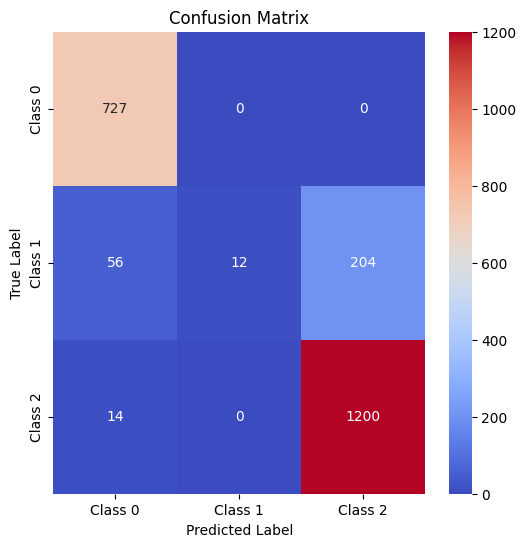

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =============================
# Evaluation function
# =============================
def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # FIX: Access logits whether model returns SequenceClassifierOutput or logits directly
            logits = outputs.logits if hasattr(outputs, 'logits') else outputs

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm)

# =============================
# Plotting Confusion Matrix
# =============================
def plot_confusion_matrix(cm):
    plt.figure(figsize=(6,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="coolwarm",  # your preferred color
        cbar=True,
        xticklabels=["Class 0","Class 1","Class 2"],
        yticklabels=["Class 0","Class 1","Class 2"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# =============================
# Run evaluation
# =============================
evaluate_model(model, val_dataloader, device)


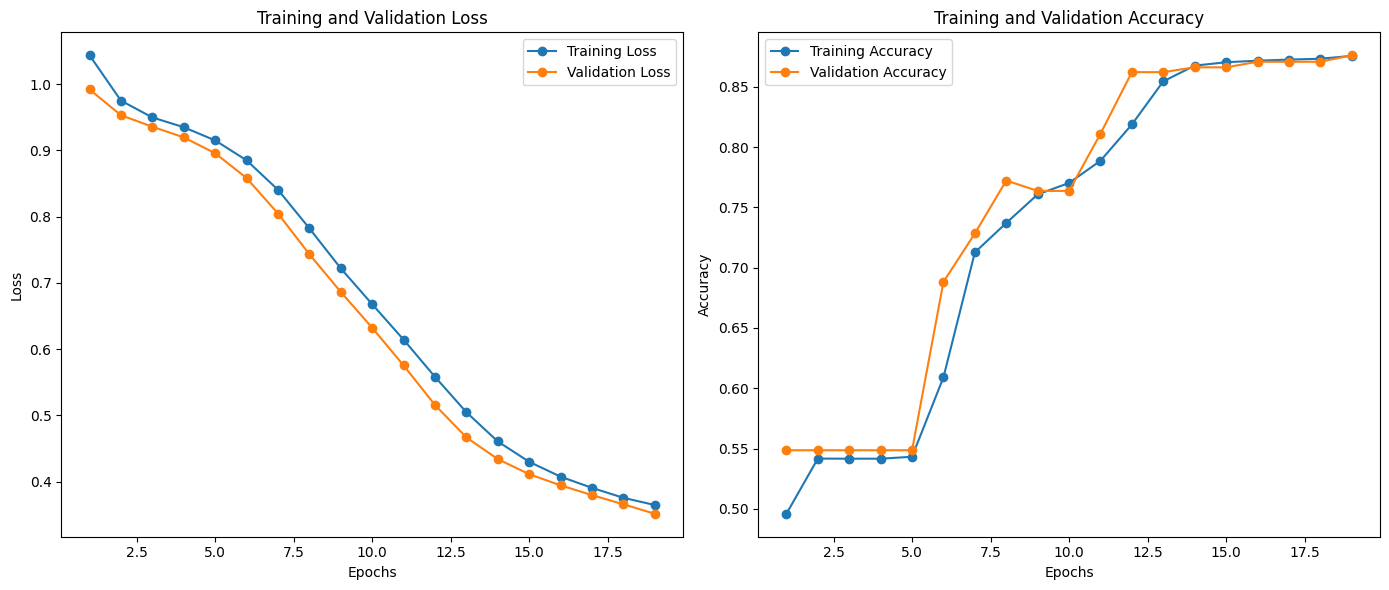

In [ ]:
import matplotlib.pyplot as plt

# ============================
# Training logs
# ============================
epochs = list(range(1, 20))  # 19 epochs

train_loss = [1.0435, 0.9750, 0.9497, 0.9349, 0.9150, 0.8850, 0.8405, 0.7823, 0.7219,
              0.6678, 0.6143, 0.5582, 0.5048, 0.4607, 0.4300, 0.4076, 0.3907, 0.3757, 0.3648]

val_loss = [0.9919, 0.9530, 0.9357, 0.9195, 0.8957, 0.8582, 0.8047, 0.7432, 0.6863,
            0.6323, 0.5754, 0.5157, 0.4668, 0.4341, 0.4113, 0.3945, 0.3798, 0.3659, 0.3516]

train_acc = [0.4959, 0.5417, 0.5416, 0.5416, 0.5432, 0.6091, 0.7127, 0.7371, 0.7608,
             0.7703, 0.7887, 0.8188, 0.8546, 0.8676, 0.8704, 0.8717, 0.8726, 0.8733, 0.8757]

val_acc = [0.5486, 0.5486, 0.5486, 0.5486, 0.5486, 0.6882, 0.7284, 0.7723, 0.7637,
           0.7637, 0.8111, 0.8622, 0.8622, 0.8662, 0.8662, 0.8708, 0.8708, 0.8708, 0.8762]

# ============================
# Plotting
# ============================
plt.figure(figsize=(14, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(False)  # removed background grid
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label='Training Accuracy', marker='o')
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(False)  # removed background grid
plt.legend()

plt.tight_layout()
plt.show()
